## **FASTER R-CNN**

In [ ]:
!pip install -q torchvision tqdm pycocotools matplotlib seaborn

In [ ]:
import zipfile, shutil, time, math, os, random
from pathlib import Path
from collections import defaultdict

import yaml
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.cuda.amp import autocast, GradScaler
from PIL import Image as PILImage, ImageFilter
from google.colab import drive, files

1. MOUNTING DRIVE

In [ ]:
drive.mount("/content/drive")

DRIVE_DIR     = Path("/content/drive/MyDrive/PPE_FasterRCNN_Final")
DRIVE_RESULTS = DRIVE_DIR / "results"
METRICS_LOG   = DRIVE_RESULTS / "metrics_summary.txt"
DRIVE_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.mem_get_info()[1]/1e9:.1f} GB")

Mounted at /content/drive
Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


2. UPLOADING + EXTRACTING

In [ ]:
print("Select your dataset ZIP:")
uploaded = files.upload()

ZIP_PATH = Path(next(iter(uploaded)))
DATA_DIR = Path("/content/ppe_data")

if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(DATA_DIR)
print(f"Extracted to: {DATA_DIR}")

Select your dataset ZIP:


Saving Roboflow.zip to Roboflow.zip
Extracted to: /content/ppe_data


3. LOCATING data.yaml

In [ ]:
yaml_candidates = list(DATA_DIR.rglob("*.yaml")) + list(DATA_DIR.rglob("*.yml"))
if not yaml_candidates:
    raise FileNotFoundError("No YAML found in dataset.")

DATA_YAML = yaml_candidates[0]

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

def find_dataset_root(base: Path) -> Path:
    for p in base.rglob("train"):
        if (p / "images").exists():
            return p.parent
    raise RuntimeError("Cannot locate train/images.")

DATASET_ROOT = find_dataset_root(DATA_DIR)
cfg["path"]  = str(DATASET_ROOT)
cfg["train"] = "train/images"
cfg["val"]   = "valid/images"
cfg["test"]  = "test/images"

with open(DATA_YAML, "w") as f:
    yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)

CLASS_NAMES = cfg["names"]
NUM_CLASSES = len(CLASS_NAMES) + 1   # +1 for background
print(f"Dataset root : {DATASET_ROOT}")
print(f"Classes ({len(CLASS_NAMES)}) : {CLASS_NAMES}")
print(f"NUM_CLASSES  : {NUM_CLASSES}")

Dataset root : /content/ppe_data/css-data
Classes (10) : ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']
NUM_CLASSES  : 11


4. SANITY CHECKING

In [ ]:
def verify_split(split):
    img_dir = DATASET_ROOT / split / "images"
    lbl_dir = DATASET_ROOT / split / "labels"
    if not img_dir.exists(): raise RuntimeError(f"Missing: {img_dir}")
    if not lbl_dir.exists(): raise RuntimeError(f"Missing: {lbl_dir}")
    images = list(img_dir.glob("*.[jp][pn]g")) + list(img_dir.glob("*.jpeg"))
    labels = list(lbl_dir.glob("*.txt"))
    if not images: raise RuntimeError(f"No images in {img_dir}")
    if not labels: raise RuntimeError(f"No labels in {lbl_dir}")
    print(f"  {split:<6}  {len(images):>5} images  {len(labels):>5} labels")

print("Verifying splits:")
for s in ("train", "valid", "test"):
    verify_split(s)

Verifying splits:
  train    2605 images   2605 labels
  valid     114 images    114 labels
  test       82 images     82 labels


5. EDA (CLASS DISTRIBUTION)

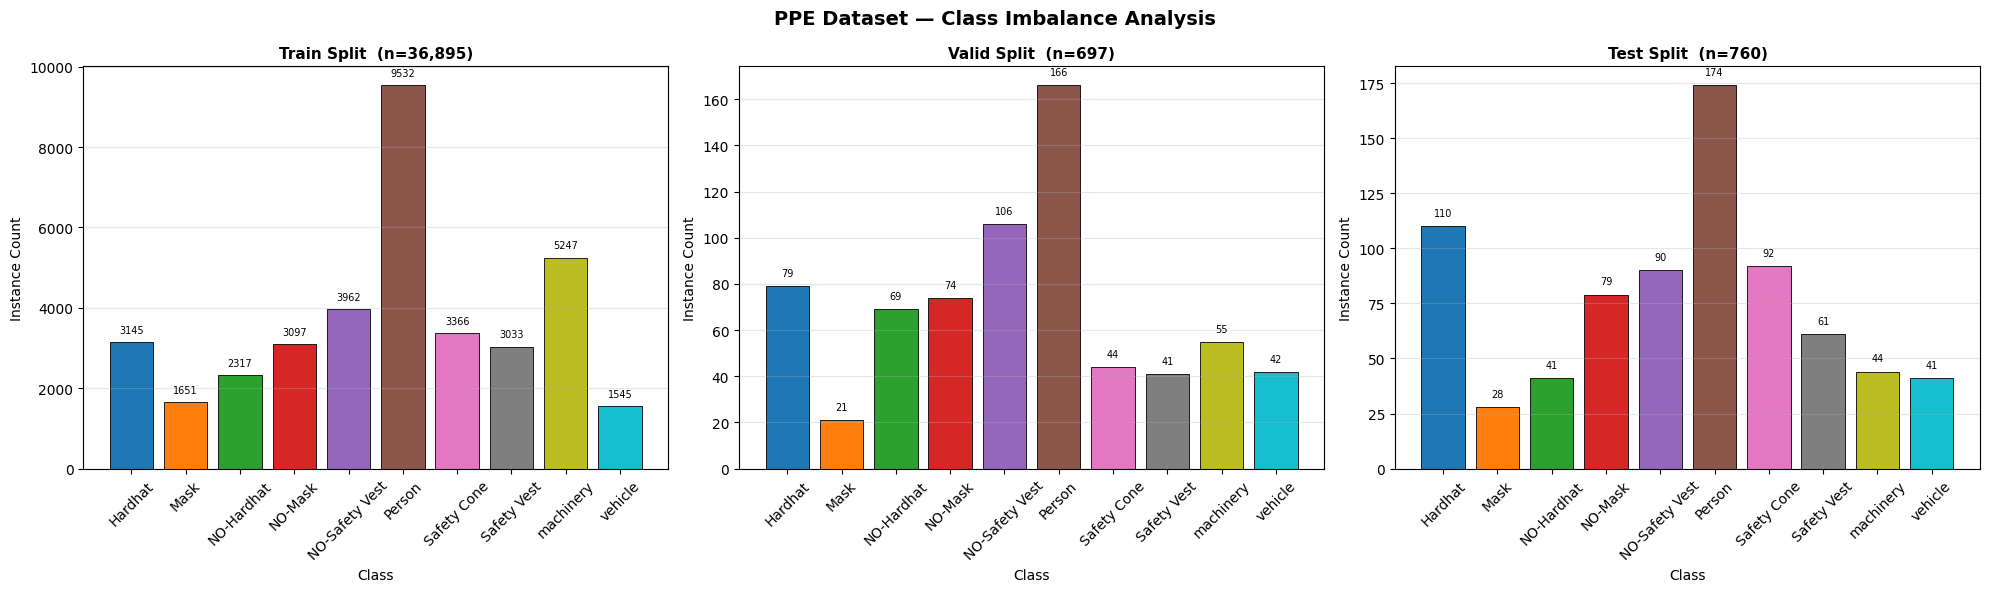

In [ ]:
def count_classes(split):
    counts = defaultdict(int)
    lbl_dir = DATASET_ROOT / split / "labels"
    for f in lbl_dir.glob("*.txt"):
        for line in f.read_text().splitlines():
            parts = line.strip().split()
            if parts:
                counts[int(parts[0])] += 1
    return counts

split_counts = {s: count_classes(s) for s in ("train", "valid", "test")}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
palette = plt.cm.tab10.colors

for ax, (split, counts) in zip(axes, split_counts.items()):
    vals  = [counts.get(i, 0) for i in range(len(CLASS_NAMES))]
    total = sum(vals)
    bars  = ax.bar(CLASS_NAMES, vals,
                   color=palette[:len(CLASS_NAMES)],
                   edgecolor="black", linewidth=0.6)
    ax.set_title(f"{split.capitalize()} Split  (n={total:,})",
                 fontweight="bold", fontsize=11)
    ax.set_xlabel("Class"); ax.set_ylabel("Instance Count")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + total*0.005,
                str(val), ha="center", va="bottom", fontsize=7)

plt.suptitle("PPE Dataset — Class Imbalance Analysis",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(DRIVE_RESULTS / "eda_class_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

6. DATASET WITH COPY-PASTE AUGMENTATION

In [ ]:
# ---------------------------------------------------------------------------
# Design decisions (locked — do not change):
#
#   NO mosaic   — halves object size, breaks RPN anchor matching
#   NO rotation — corrupts axis-aligned bounding boxes
#   NO aggressive scale jitter — pushes small PPE below 32px anchor floor
#
#   Copy-paste  — correct R-CNN imbalance fix: pastes rare-class objects
#                 onto other images at FULL resolution, so anchors always
#                 match. This is the architecturally sound mosaic alternative.
#
#   WeightedRandomSampler — over-samples rare-class images at epoch level.
#                           Works at the image level, not pixel level.
# ---------------------------------------------------------------------------

def load_sample(img_path: Path, lbl_dir: Path, img_size: int):
    """Load one image + boxes at target resolution. Returns PIL image,
    list of [x1,y1,x2,y2] boxes, and list of int labels (1-indexed)."""
    img = PILImage.open(img_path).convert("RGB").resize(
        (img_size, img_size), PILImage.BILINEAR
    )
    w, h   = img.size
    boxes, labels = [], []
    lbl_path = lbl_dir / (img_path.stem + ".txt")
    if lbl_path.exists():
        for line in lbl_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls, cx, cy, bw, bh = map(float, parts)
            x1 = max(0.0,       (cx - bw/2) * w)
            y1 = max(0.0,       (cy - bh/2) * h)
            x2 = min(float(w),  (cx + bw/2) * w)
            y2 = min(float(h),  (cy + bh/2) * h)
            if x2 > x1 + 2 and y2 > y1 + 2:
                boxes.append([x1, y1, x2, y2])
                labels.append(int(cls) + 1)
    return img, boxes, labels


def copy_paste(base_img, base_boxes, base_labels,
               donor_img, donor_boxes, donor_labels,
               rare_classes: set, p: float = 0.5):
    """
    Paste objects of rare_classes from donor onto base image.
    Objects are pasted at their original crop size — no resizing.
    Boxes are adjusted with a small random positional jitter.
    Only pastes if donor actually contains a rare class object.
    """
    if random.random() > p:
        return base_img, base_boxes, base_labels

    rare_indices = [
        i for i, lbl in enumerate(donor_labels)
        if lbl in rare_classes
    ]
    if not rare_indices:
        return base_img, base_boxes, base_labels

    img_out    = base_img.copy()
    boxes_out  = list(base_boxes)
    labels_out = list(base_labels)
    W, H       = img_out.size

    for i in rare_indices:
        x1, y1, x2, y2 = [int(v) for v in donor_boxes[i]]
        obj_w = x2 - x1
        obj_h = y2 - y1
        if obj_w < 4 or obj_h < 4:
            continue

        crop = donor_img.crop((x1, y1, x2, y2))

        # Random placement with boundary clamping
        max_ox = max(0, W - obj_w)
        max_oy = max(0, H - obj_h)
        ox = random.randint(0, max_ox)
        oy = random.randint(0, max_oy)

        img_out.paste(crop, (ox, oy))

        nx1 = float(ox)
        ny1 = float(oy)
        nx2 = float(ox + obj_w)
        ny2 = float(oy + obj_h)
        boxes_out.append([nx1, ny1, nx2, ny2])
        labels_out.append(donor_labels[i])

    return img_out, boxes_out, labels_out


class PPEDataset(Dataset):
    def __init__(self, root: Path, split: str, img_size: int,
                 augment: bool, rare_classes: set = None):
        self.img_dir      = root / split / "images"
        self.lbl_dir      = root / split / "labels"
        self.img_size     = img_size
        self.augment      = augment
        self.rare_classes = rare_classes or set()
        self.samples      = sorted(
            p for p in self.img_dir.iterdir()
            if p.suffix.lower() in (".jpg", ".jpeg", ".png")
        )

    def __len__(self):
        return len(self.samples)

    def _augment(self, img, boxes, labels):
        w, h = img.size

        # 1. Horizontal flip — p=0.5
        if random.random() < 0.5:
            img   = TF.hflip(img)
            boxes = [[w - x2, y1, w - x1, y2]
                     for x1, y1, x2, y2 in boxes]

        # 2. Mild scale jitter [0.9, 1.1] only — keeps objects above anchor floor
        scale    = random.uniform(0.9, 1.1)
        new_size = max(1, int(self.img_size * scale))
        img      = img.resize((new_size, new_size), PILImage.BILINEAR)
        boxes    = [[x1*scale, y1*scale, x2*scale, y2*scale]
                    for x1, y1, x2, y2 in boxes]

        if scale > 1.0:
            offset = (new_size - self.img_size) / 2
            img    = TF.center_crop(img, self.img_size)
            boxes  = [[x1-offset, y1-offset, x2-offset, y2-offset]
                      for x1, y1, x2, y2 in boxes]
        else:
            pad   = (self.img_size - new_size) // 2
            img   = TF.pad(img, pad)
            boxes = [[x1+pad, y1+pad, x2+pad, y2+pad]
                     for x1, y1, x2, y2 in boxes]

        # 3. Colour jitter — HSV equivalent
        img = T.ColorJitter(
            brightness=0.4, contrast=0.4,
            saturation=0.7, hue=0.015
        )(img)

        # 4. Gaussian blur — p=0.2
        if random.random() < 0.2:
            img = img.filter(ImageFilter.GaussianBlur(radius=1))

        # 5. Grayscale — p=0.1
        if random.random() < 0.1:
            img = TF.to_grayscale(img, num_output_channels=3)

        # Clamp boxes and drop degenerates
        S     = float(self.img_size)
        boxes = [[max(0.,x1), max(0.,y1), min(S,x2), min(S,y2)]
                 for x1, y1, x2, y2 in boxes]
        valid = [(b, l) for b, l in zip(boxes, labels)
                 if b[2] > b[0]+2 and b[3] > b[1]+2]
        if valid:
            boxes, labels = zip(*valid)
            return img, list(boxes), list(labels)
        return img, [], []

    def __getitem__(self, idx):
        img, boxes, labels = load_sample(
            self.samples[idx], self.lbl_dir, self.img_size
        )

        # Copy-paste from a random donor image (training only)
        if self.augment and self.rare_classes:
            donor_idx              = random.randint(0, len(self.samples)-1)
            d_img, d_boxes, d_lbls = load_sample(
                self.samples[donor_idx], self.lbl_dir, self.img_size
            )
            img, boxes, labels = copy_paste(
                img, boxes, labels,
                d_img, d_boxes, d_lbls,
                self.rare_classes, p=0.5
            )

        if self.augment and boxes:
            img, boxes, labels = self._augment(img, boxes, labels)

        tensor = TF.to_tensor(img)

        if boxes:
            target = {
                "boxes":  torch.tensor(boxes,  dtype=torch.float32),
                "labels": torch.tensor(labels, dtype=torch.int64),
            }
        else:
            target = {
                "boxes":  torch.zeros((0, 4), dtype=torch.float32),
                "labels": torch.zeros((0,),   dtype=torch.int64),
            }
        return tensor, target


def collate_fn(batch):
    return tuple(zip(*batch))

7. WEIGHTED SAMPLER

In [ ]:
def build_weighted_sampler(dataset: PPEDataset):
    lbl_dir      = dataset.lbl_dir
    class_counts = defaultdict(int)

    for p in lbl_dir.glob("*.txt"):
        for line in p.read_text().splitlines():
            parts = line.strip().split()
            if parts:
                class_counts[int(parts[0])] += 1

    total        = sum(class_counts.values()) or 1
    class_weight = {
        c: total / (len(class_counts) * max(n, 1))
        for c, n in class_counts.items()
    }

    sample_weights = []
    for img_path in dataset.samples:
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        w = 1.0
        if lbl_path.exists():
            cls_in_img = set()
            for line in lbl_path.read_text().splitlines():
                parts = line.strip().split()
                if parts:
                    cls_in_img.add(int(parts[0]))
            if cls_in_img:
                w = max(class_weight.get(c, 1.0) for c in cls_in_img)
        sample_weights.append(w)

    return WeightedRandomSampler(
        weights     = sample_weights,
        num_samples = len(sample_weights),
        replacement = True,
    )


def get_rare_classes(split_counts: dict, threshold: float = 0.5) -> set:
    """
    Classes whose instance count is below `threshold` * mean count
    are considered rare and targeted by copy-paste.
    Returns set of 1-indexed class IDs (matching dataset label convention).
    """
    train_counts = split_counts["train"]
    counts_list  = [train_counts.get(i, 0) for i in range(len(CLASS_NAMES))]
    mean_count   = np.mean(counts_list) if counts_list else 1.0
    rare = {
        i + 1   # 1-indexed
        for i, cnt in enumerate(counts_list)
        if cnt < threshold * mean_count
    }
    rare_names = [CLASS_NAMES[i-1] for i in rare]
    print(f"Rare classes (copy-paste targets): {rare_names}")
    return rare

RARE_CLASSES = get_rare_classes(split_counts, threshold=0.5)

Rare classes (copy-paste targets): ['Mask', 'vehicle']


8. HYPERPARAMETERS + DATA LOADERS

In [ ]:
IMG_SIZE      = 640
EPOCHS        = 25
PATIENCE      = 10
BATCH         = 4
LR_HEAD       = 1e-3   # standard torchvision fine-tuning rate
LR_BACKBONE   = 1e-4   # 10x lower — protects pretrained weights
WEIGHT_DECAY  = 5e-4
WARMUP_EPOCHS = 3
MAX_NORM      = 5.0
SEED          = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

train_dataset = PPEDataset(DATASET_ROOT, "train", IMG_SIZE,
                           augment=True, rare_classes=RARE_CLASSES)
val_dataset   = PPEDataset(DATASET_ROOT, "valid", IMG_SIZE,
                           augment=False)

sampler = build_weighted_sampler(train_dataset)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH,
    sampler     = sampler,
    num_workers = 2,
    collate_fn  = collate_fn,
    pin_memory  = True,
    drop_last   = True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH,
    shuffle     = False,
    num_workers = 2,
    collate_fn  = collate_fn,
    pin_memory  = True,
)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")

Train batches : 651
Val   batches : 29


9. MODEL + OPTIMIZER

In [ ]:
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

# Replace classification head for our number of classes
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

# Inference thresholds — low at train time so loss dict is computed on
# more proposals; overridden to 0.01 at evaluation for correct AP sweep
model.roi_heads.score_thresh       = 0.05
model.roi_heads.nms_thresh         = 0.4
model.roi_heads.detections_per_img = 100

# Correct RPN attribute paths
model.rpn.pre_nms_top_n_train  = 2000
model.rpn.post_nms_top_n_train = 1000
model.rpn.pre_nms_top_n_test   = 1000
model.rpn.post_nms_top_n_test  = 500

model.to(DEVICE)

backbone_params = [p for n, p in model.named_parameters()
                   if "backbone" in n and p.requires_grad]
head_params     = [p for n, p in model.named_parameters()
                   if "backbone" not in n and p.requires_grad]

optimizer = optim.SGD(
    [{"params": backbone_params, "lr": LR_BACKBONE},
     {"params": head_params,     "lr": LR_HEAD}],
    momentum     = 0.9,
    weight_decay = WEIGHT_DECAY,
    nesterov     = True,
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=LR_HEAD * 0.01
)
scaler = GradScaler(enabled=torch.cuda.is_available())

RUNS_DIR  = Path("runs/ppe_final")
EXP_DIR   = RUNS_DIR / "fasterrcnn"
EXP_DIR.mkdir(parents=True, exist_ok=True)
BEST_CKPT = EXP_DIR / "best.pt"
LAST_CKPT = EXP_DIR / "last.pt"

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Total params : {total_params:.1f}M")
print(f"Backbone LR  : {LR_BACKBONE}")
print(f"Head LR      : {LR_HEAD}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 166MB/s]


Total params : 41.3M
Backbone LR  : 0.0001
Head LR      : 0.001


/tmp/ipykernel_1221/3072493483.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())


10. TRAINING

In [ ]:
def set_warmup_lr(optimizer, epoch, warmup_epochs):
    if epoch < warmup_epochs:
        factor = (epoch + 1) / warmup_epochs
        optimizer.param_groups[0]["lr"] = LR_BACKBONE * factor
        optimizer.param_groups[1]["lr"] = LR_HEAD     * factor


best_val_loss  = float("inf")
epochs_no_impr = 0
history        = []

print(f"{'='*65}")
print(f"  Faster R-CNN — PPE Compliance Training")
print(f"  Epochs={EPOCHS}  Batch={BATCH}  ImgSize={IMG_SIZE}  Device={DEVICE}")
print(f"{'='*65}")

try:
    for epoch in range(EPOCHS):
        ep = epoch + 1
        set_warmup_lr(optimizer, epoch, WARMUP_EPOCHS)

        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        train_loss_sum = 0.0
        t0 = time.time()

        for images, targets in train_loader:
            # Filter empty-annotation samples before forward pass
            pairs = [(im, tg) for im, tg in zip(images, targets)
                     if tg["boxes"].shape[0] > 0]
            if not pairs:
                continue

            imgs, tgts = zip(*pairs)
            imgs = [im.to(DEVICE) for im in imgs]
            tgts = [{k: v.to(DEVICE) for k, v in t.items()} for t in tgts]

            with autocast(enabled=torch.cuda.is_available()):
                loss_dict = model(list(imgs), list(tgts))
                loss      = sum(loss_dict.values())

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                backbone_params + head_params, MAX_NORM)
            scaler.step(optimizer)
            scaler.update()

            train_loss_sum += loss.item()

        if epoch >= WARMUP_EPOCHS:
            scheduler.step()

        train_loss_avg = train_loss_sum / len(train_loader)

        # ── Validation loss ────────────────────────────────────────────────
        # model.train() kept intentionally — Faster R-CNN only returns a
        # loss dict in train mode; eval mode returns predictions only
        val_loss_sum = 0.0
        model.train()
        with torch.no_grad():
            for images, targets in val_loader:
                imgs = [im.to(DEVICE) for im in images]
                tgts = [{k: v.to(DEVICE) for k, v in t.items()}
                        for t in targets]
                val_loss_sum += sum(model(imgs, tgts).values()).item()

        val_loss_avg = val_loss_sum / len(val_loader)
        current_lr   = optimizer.param_groups[1]["lr"]

        history.append({
            "epoch":      ep,
            "train_loss": train_loss_avg,
            "val_loss":   val_loss_avg,
            "lr":         current_lr,
        })

        print(f"Epoch {ep:>3}/{EPOCHS}  "
              f"train={train_loss_avg:.4f}  "
              f"val={val_loss_avg:.4f}  "
              f"lr={current_lr:.2e}  "
              f"time={time.time()-t0:.0f}s")

        torch.save(model.state_dict(), LAST_CKPT)

        # Drive checkpoint every 5 epochs
        if ep % 5 == 0:
            ckpt = DRIVE_RESULTS / f"checkpoint_ep{ep}.pt"
            torch.save(model.state_dict(), ckpt)
            print(f"  Checkpoint saved: {ckpt}")

        if val_loss_avg < best_val_loss:
            best_val_loss  = val_loss_avg
            epochs_no_impr = 0
            torch.save(model.state_dict(), BEST_CKPT)
            print(f"  Best model saved  (val_loss={best_val_loss:.4f})")
        else:
            epochs_no_impr += 1
            if epochs_no_impr >= PATIENCE:
                print(f"Early stopping triggered at epoch {ep}.")
                break

except RuntimeError as e:
    if "out of memory" in str(e).lower():
        torch.cuda.empty_cache()
        print("[OOM] Lower BATCH to 2 and rerun from Cell 10.")
    raise

  Faster R-CNN — PPE Compliance Training
  Epochs=25  Batch=4  ImgSize=640  Device=cuda


/tmp/ipykernel_1221/17625727.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


Epoch   1/25  train=2.1253  val=0.7978  lr=3.33e-04  time=301s
  Best model saved  (val_loss=0.7978)
Epoch   2/25  train=1.5289  val=0.6628  lr=6.67e-04  time=299s
  Best model saved  (val_loss=0.6628)
Epoch   3/25  train=1.3857  val=0.6133  lr=1.00e-03  time=299s
  Best model saved  (val_loss=0.6133)
Epoch   4/25  train=1.3186  val=0.5984  lr=9.96e-04  time=299s
  Best model saved  (val_loss=0.5984)
Epoch   5/25  train=1.2797  val=0.5898  lr=9.84e-04  time=298s
  Checkpoint saved: /content/drive/MyDrive/PPE_FasterRCNN_Final/results/checkpoint_ep5.pt
  Best model saved  (val_loss=0.5898)
Epoch   6/25  train=1.2322  val=0.5767  lr=9.65e-04  time=299s
  Best model saved  (val_loss=0.5767)
Epoch   7/25  train=1.2104  val=0.5651  lr=9.39e-04  time=298s
  Best model saved  (val_loss=0.5651)
Epoch   8/25  train=1.1928  val=0.5689  lr=9.05e-04  time=300s
Epoch   9/25  train=1.1768  val=0.5610  lr=8.66e-04  time=299s
  Best model saved  (val_loss=0.5610)
Epoch  10/25  train=1.1643  val=0.5490 

11. TRAINING CURVES

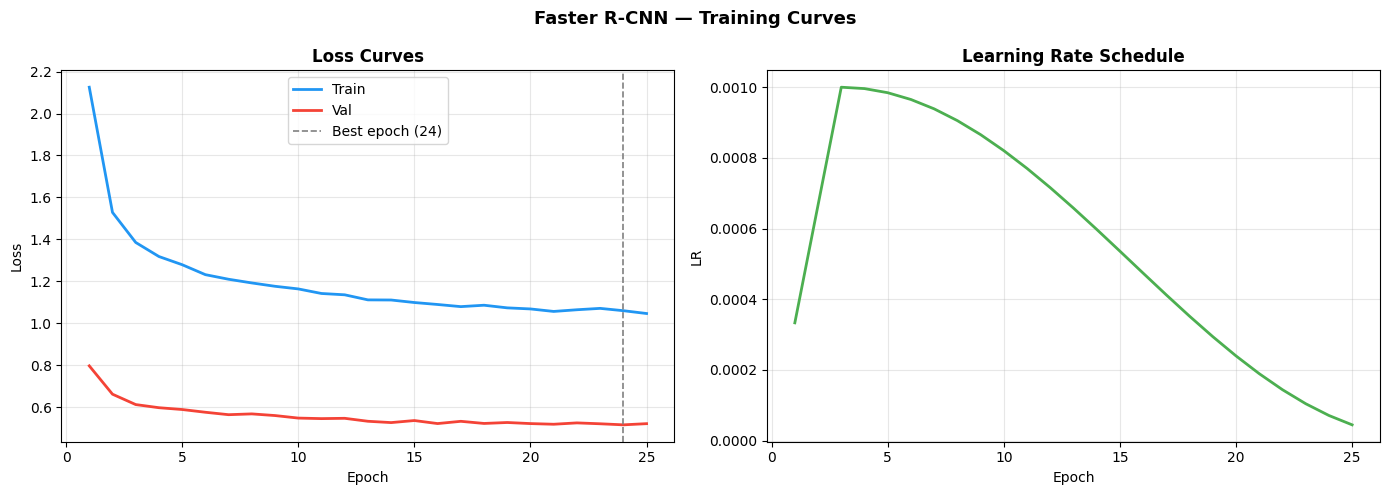

In [ ]:
epochs_x     = [h["epoch"]      for h in history]
train_losses = [h["train_loss"] for h in history]
val_losses   = [h["val_loss"]   for h in history]
lr_curve     = [h["lr"]         for h in history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_x, train_losses, label="Train",
             color="#2196F3", linewidth=2)
axes[0].plot(epochs_x, val_losses,   label="Val",
             color="#F44336", linewidth=2)
best_ep = epochs_x[int(np.argmin(val_losses))]
axes[0].axvline(best_ep, color="gray", linestyle="--",
                linewidth=1.2, label=f"Best epoch ({best_ep})")
axes[0].set_title("Loss Curves", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_x, lr_curve, color="#4CAF50", linewidth=2)
axes[1].set_title("Learning Rate Schedule", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("LR")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Faster R-CNN — Training Curves",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DRIVE_RESULTS / "training_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()

12. EVALUATION

In [ ]:
model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE))
model.roi_heads.score_thresh = 0.01   # low threshold → full PR curve sweep
model.roi_heads.nms_thresh   = 0.4
model.eval()

test_dataset = PPEDataset(DATASET_ROOT, "test", IMG_SIZE, augment=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH, shuffle=False,
                          num_workers=2, collate_fn=collate_fn,
                          pin_memory=True)
print(f"Test images : {len(test_dataset)}")


def box_iou(box_a: torch.Tensor, box_b: torch.Tensor) -> torch.Tensor:
    ax1,ay1,ax2,ay2 = box_a[:,0],box_a[:,1],box_a[:,2],box_a[:,3]
    bx1,by1,bx2,by2 = box_b[:,0],box_b[:,1],box_b[:,2],box_b[:,3]
    ix1 = torch.max(ax1.unsqueeze(1), bx1.unsqueeze(0))
    iy1 = torch.max(ay1.unsqueeze(1), by1.unsqueeze(0))
    ix2 = torch.min(ax2.unsqueeze(1), bx2.unsqueeze(0))
    iy2 = torch.min(ay2.unsqueeze(1), by2.unsqueeze(0))
    inter  = (ix2-ix1).clamp(0) * (iy2-iy1).clamp(0)
    area_a = (ax2-ax1) * (ay2-ay1)
    area_b = (bx2-bx1) * (by2-by1)
    return inter / (area_a.unsqueeze(1) + area_b.unsqueeze(0) - inter).clamp(1e-6)


def compute_ap_11point(recalls: np.ndarray,
                       precisions: np.ndarray) -> float:
    ap = 0.0
    for thr in np.linspace(0, 1, 11):
        p   = precisions[recalls >= thr]
        ap += p.max() if p.size > 0 else 0.0
    return ap / 11.0


# all_preds stores (confidence_score, iou_with_best_gt) per class.
# Storing raw IoU allows correct AP computation at any threshold —
# this is the fix for the mAP50-95 bug in previous versions.
all_preds = {c: [] for c in range(1, NUM_CLASSES)}
all_gts   = {c: 0  for c in range(1, NUM_CLASSES)}
cm        = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)

print("Running evaluation...")

with torch.no_grad():
    for images, targets in test_loader:
        images = [im.to(DEVICE) for im in images]
        preds  = model(images)

        for pred, target in zip(preds, targets):
            gt_boxes  = target["boxes"].cpu()
            gt_labels = target["labels"].cpu()

            for c in range(1, NUM_CLASSES):
                all_gts[c] += (gt_labels == c).sum().item()

            if pred["boxes"].shape[0] == 0:
                for c in range(1, NUM_CLASSES):
                    cm[c, 0] += (gt_labels == c).sum().item()
                continue

            p_boxes  = pred["boxes"].cpu()
            p_scores = pred["scores"].cpu()
            p_labels = pred["labels"].cpu()

            # Confusion matrix at IoU=0.5
            if gt_boxes.shape[0] > 0:
                iou_mat = box_iou(p_boxes, gt_boxes)
                for pi in range(p_boxes.shape[0]):
                    best_iou, best_gi = iou_mat[pi].max(0)
                    pred_cls = p_labels[pi].item()
                    if best_iou.item() >= 0.5:
                        cm[gt_labels[best_gi].item(), pred_cls] += 1
                    else:
                        cm[0, pred_cls] += 1

            # Per-class AP accumulation
            for c in range(1, NUM_CLASSES):
                p_mask = p_labels == c
                g_mask = gt_labels == c
                if p_mask.sum() == 0:
                    continue

                p_b      = p_boxes[p_mask]
                p_s      = p_scores[p_mask]
                g_b      = gt_boxes[g_mask]
                sort_idx = p_s.argsort(descending=True)
                p_b, p_s = p_b[sort_idx], p_s[sort_idx]
                matched  = torch.zeros(g_b.shape[0], dtype=torch.bool)

                for i, pb in enumerate(p_b):
                    if g_b.shape[0] > 0:
                        iou_vals         = box_iou(pb.unsqueeze(0), g_b)[0]
                        best_iou, best_j = iou_vals.max(0)
                        best_iou_val     = best_iou.item()
                        best_j_val       = best_j.item()
                        if (best_iou_val >= 0.5
                                and not matched[best_j_val].item()):
                            matched[best_j_val] = True
                            tp_iou = best_iou_val
                        else:
                            # FP — store 0.0 so it never counts as TP
                            # at any threshold (fixes previous mAP50-95 bug)
                            tp_iou = 0.0
                    else:
                        tp_iou = 0.0
                    all_preds[c].append((p_s[i].item(), tp_iou))


def compute_ap_at_iou(preds_list, n_gt, iou_thr):
    if n_gt == 0:
        return float("nan")
    if not preds_list:
        return 0.0
    preds_list   = sorted(preds_list, key=lambda x: -x[0])
    tp_arr       = np.array([1. if iou >= iou_thr else 0.
                             for _, iou in preds_list])
    fp_arr       = 1.0 - tp_arr
    tp_cum       = np.cumsum(tp_arr)
    fp_cum       = np.cumsum(fp_arr)
    recalls      = tp_cum / max(n_gt, 1)
    precisions   = tp_cum / (tp_cum + fp_cum + 1e-9)
    return compute_ap_11point(recalls, precisions)


IOU_THRESHOLDS = np.arange(0.50, 1.00, 0.05)

per_class_ap50 = {
    c: compute_ap_at_iou(all_preds[c], all_gts[c], 0.5)
    for c in range(1, NUM_CLASSES)
}
valid_aps    = [v for v in per_class_ap50.values() if not math.isnan(v)]
global_map50 = float(np.mean(valid_aps)) if valid_aps else 0.0

map_per_iou = []
for iou_thr in IOU_THRESHOLDS:
    aps = [
        compute_ap_at_iou(all_preds[c], all_gts[c], iou_thr)
        for c in range(1, NUM_CLASSES) if all_gts[c] > 0
    ]
    aps = [v for v in aps if not math.isnan(v)]
    map_per_iou.append(float(np.mean(aps)) if aps else 0.0)

global_map50_95 = float(np.mean(map_per_iou))

print(f"\n{'='*52}")
print(f"  Global mAP50       : {global_map50*100:.2f}%")
print(f"  Global mAP50-95    : {global_map50_95*100:.2f}%")
print(f"{'='*52}")
for c in range(1, NUM_CLASSES):
    name  = CLASS_NAMES[c-1]
    score = per_class_ap50.get(c, float("nan"))
    val   = f"{score*100:.2f}%" if not math.isnan(score) else "  N/A"
    print(f"  {name:<28} {val}")
print(f"{'='*52}")

Test images : 82
Running evaluation...

  Global mAP50       : 61.93%
  Global mAP50-95    : 29.61%
  Hardhat                      78.42%
  Mask                         66.94%
  NO-Hardhat                   42.17%
  NO-Mask                      44.63%
  NO-Safety Vest               60.24%
  Person                       70.20%
  Safety Cone                  53.82%
  Safety Vest                  68.79%
  machinery                    76.97%
  vehicle                      57.10%


13. PER-CLASS AP CHART + CONFUSION MATRIX

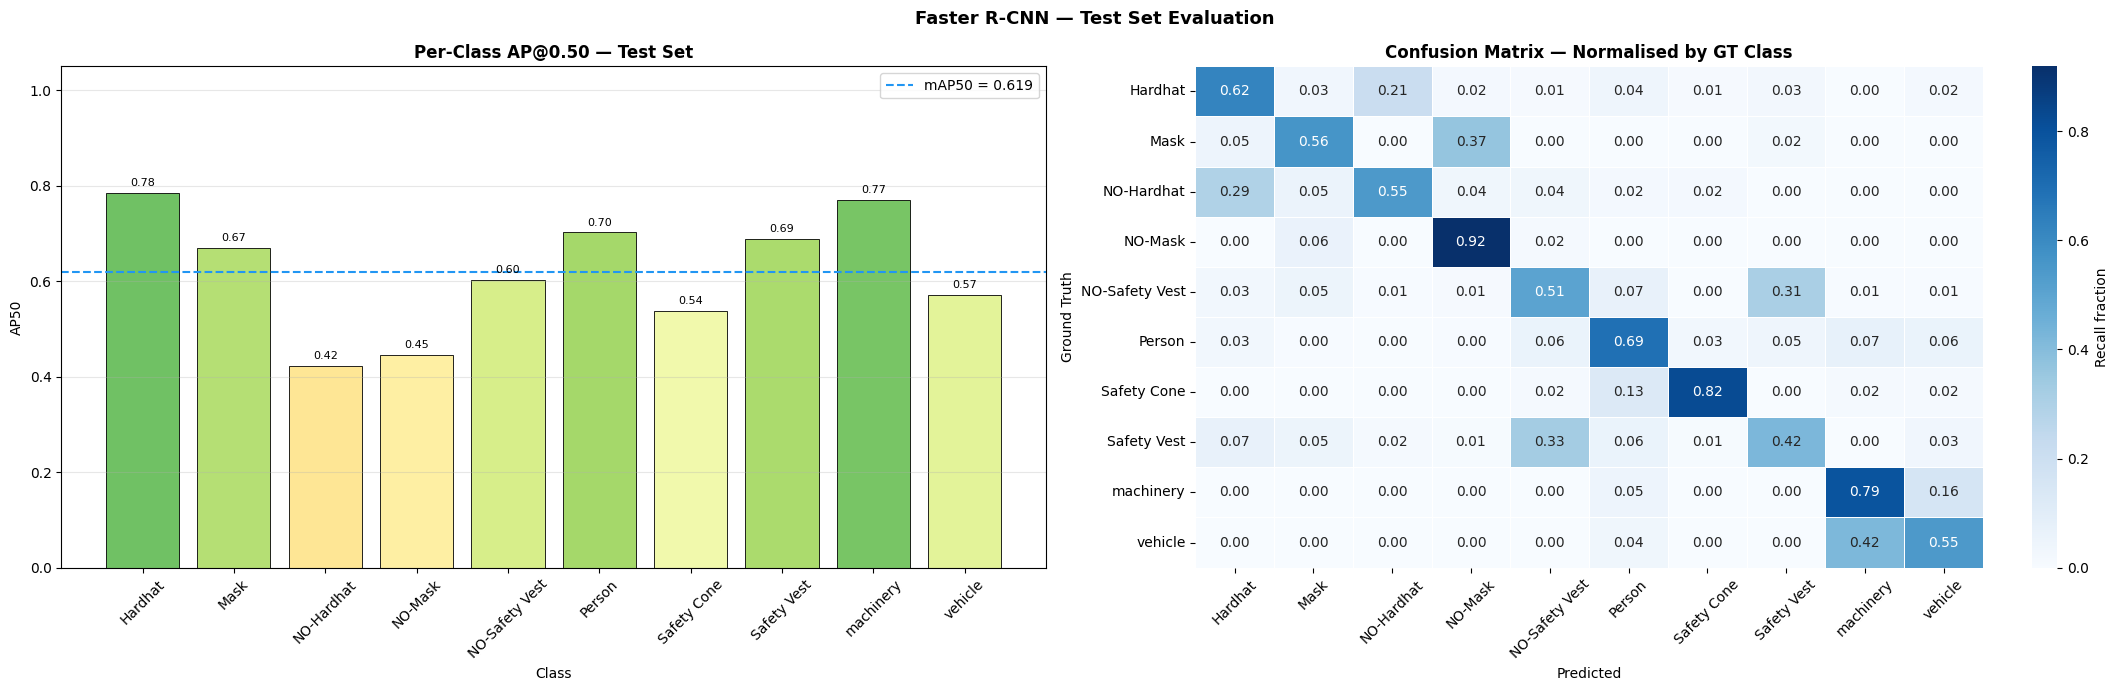

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(22, 7))

ap_clean = [
    0.0 if math.isnan(per_class_ap50.get(c, 0.)) else per_class_ap50[c]
    for c in range(1, NUM_CLASSES)
]

bars = axes[0].bar(CLASS_NAMES, ap_clean,
                   color=[plt.cm.RdYlGn(v) for v in ap_clean],
                   edgecolor="black", linewidth=0.6)
axes[0].axhline(global_map50, color="#2196F3", linestyle="--",
                linewidth=1.5, label=f"mAP50 = {global_map50:.3f}")
axes[0].set_title("Per-Class AP@0.50 — Test Set", fontweight="bold")
axes[0].set_xlabel("Class"); axes[0].set_ylabel("AP50")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)
for bar, val in zip(bars, ap_clean):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=8)

cm_obj  = cm[1:, 1:]
row_sum = cm_obj.sum(axis=1, keepdims=True).clip(min=1)
cm_norm = cm_obj / row_sum

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.4, ax=axes[1],
            cbar_kws={"label": "Recall fraction"})
axes[1].set_title("Confusion Matrix — Normalised by GT Class",
                  fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Ground Truth")
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="y", rotation=0)

plt.suptitle("Faster R-CNN — Test Set Evaluation",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DRIVE_RESULTS / "evaluation_charts.png",
            dpi=150, bbox_inches="tight")
plt.show()

14. METRICS REPORT

In [ ]:
divider = "=" * 56
lines = [
    divider,
    "  Faster R-CNN ResNet50-FPN — PPE Compliance",
    "  Copy-Paste Aug | WeightedSampler | AMP | CosLR",
    divider,
    f"  Global mAP50       : {global_map50*100:.2f}%",
    f"  Global mAP50-95    : {global_map50_95*100:.2f}%",
    "",
    "  Per-Class AP@0.50",
    "  " + "-" * 44,
]
for c in range(1, NUM_CLASSES):
    name  = CLASS_NAMES[c-1]
    score = per_class_ap50.get(c, float("nan"))
    val   = f"{score*100:.2f}%" if not math.isnan(score) else "N/A"
    lines.append(f"  {name:<30} {val}")

lines += ["", divider]
report = "\n".join(lines)
print("\n" + report)

with open(METRICS_LOG, "w") as f:
    f.write(report + "\n")

weights_path = DRIVE_RESULTS / "fasterrcnn_best.pt"
shutil.copy(BEST_CKPT, weights_path)

print(f"\nWeights : {weights_path}")
print(f"Metrics : {METRICS_LOG}")


  Faster R-CNN ResNet50-FPN — PPE Compliance
  Copy-Paste Aug | WeightedSampler | AMP | CosLR
  Global mAP50       : 61.93%
  Global mAP50-95    : 29.61%

  Per-Class AP@0.50
  --------------------------------------------
  Hardhat                        78.42%
  Mask                           66.94%
  NO-Hardhat                     42.17%
  NO-Mask                        44.63%
  NO-Safety Vest                 60.24%
  Person                         70.20%
  Safety Cone                    53.82%
  Safety Vest                    68.79%
  machinery                      76.97%
  vehicle                        57.10%


Weights : /content/drive/MyDrive/PPE_FasterRCNN_Final/results/fasterrcnn_best.pt
Metrics : /content/drive/MyDrive/PPE_FasterRCNN_Final/results/metrics_summary.txt


15. MIGRATING TO DRIVE

In [ ]:
runs_dir = Path("runs")
if runs_dir.exists():
    dest = DRIVE_RESULTS / "runs_backup"
    if dest.exists():
        shutil.rmtree(dest)
    shutil.copytree(str(runs_dir), str(dest))
    shutil.rmtree(str(runs_dir))
    print(f"runs/ backed up to: {dest}")

print("\nAll Drive outputs:")
for fn in sorted(os.listdir(DRIVE_RESULTS)):
    fpath = DRIVE_RESULTS / fn
    if fpath.is_file():
        print(f"  {fn:<48} {os.path.getsize(fpath)/1024:>8.0f} KB")
print("\nDone.")

runs/ backed up to: /content/drive/MyDrive/PPE_FasterRCNN_Final/results/runs_backup

All Drive outputs:
  checkpoint_ep10.pt                                 162026 KB
  checkpoint_ep15.pt                                 162026 KB
  checkpoint_ep20.pt                                 162026 KB
  checkpoint_ep25.pt                                 162026 KB
  checkpoint_ep5.pt                                  162026 KB
  eda_class_distribution.png                            128 KB
  evaluation_charts.png                                 211 KB
  fasterrcnn_best.pt                                 162004 KB
  metrics_summary.txt                                     1 KB
  training_curves.png                                    97 KB

Done.
